In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy import stats
from imblearn.under_sampling import RandomUnderSampler


In [2]:
df = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [6]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [8]:
scaler = StandardScaler()
df[['scaled_time', 'scaled_amount']] = scaler.fit_transform(df[['Time', 'Amount']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_time,scaled_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996562,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-1.996562,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-1.996541,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,1.641931,-0.350151
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,1.641952,-0.254117
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,1.641974,-0.081839
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,1.641974,-0.313249


In [9]:
df = df.drop('Class', axis=1).assign(Class=df['Class'])
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_time,scaled_amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,-1.996583,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.996583,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,-1.996562,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,-1.996562,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-1.996541,-0.073403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,1.641931,-0.350151,0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,1.641952,-0.254117,0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,1.641974,-0.081839,0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,1.641974,-0.313249,0


In [10]:
df= df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [11]:
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


In [12]:
X = df.drop('Class', axis=1)
y = df.dropna(subset=['Class']) # y will drop any rows with NaN in 'Class'
X = X.dropna(subset=df.columns.difference(['Class'])) # X will also drop rows if NaN is in any column except 'Class', including the index in this case

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
       X, y, test_size=0.2, random_state=42)

#EDA#

In [14]:
# Handle outliers using Z-score method
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).all(axis=1)  # Identify outliers (Z-score > 3)
print(f"Number of outlier rows: {outliers.sum()}")



Number of outlier rows: 0


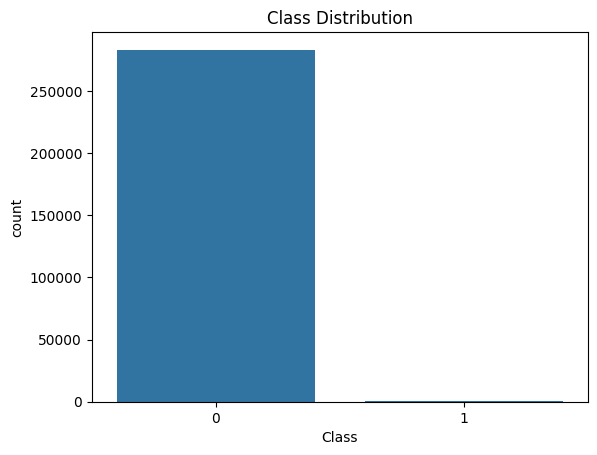

Fraudulent transactions: 0.1667%


In [15]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

# Percentage of fraud cases
fraud_percent = df['Class'].value_counts(normalize=True)[1] * 100
print(f"Fraudulent transactions: {fraud_percent:.4f}%")


In [16]:
y = df['Class']
minority_class_count = y.value_counts()[1]
majority_class_target = minority_class_count * 4
sampling_strategy = {0: min(majority_class_target, y.value_counts()[0]), 1: minority_class_count}
under_sampler = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X, y)
print("Class distribution after under-sampling:\n", pd.Series(y_resampled).value_counts())


Class distribution after under-sampling:
 Class
0    1892
1     473
Name: count, dtype: int64


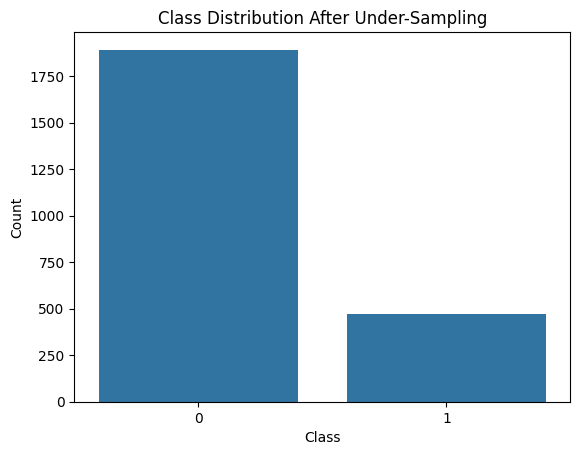

In [17]:
sns.countplot(x=y_resampled)
plt.title("Class Distribution After Under-Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


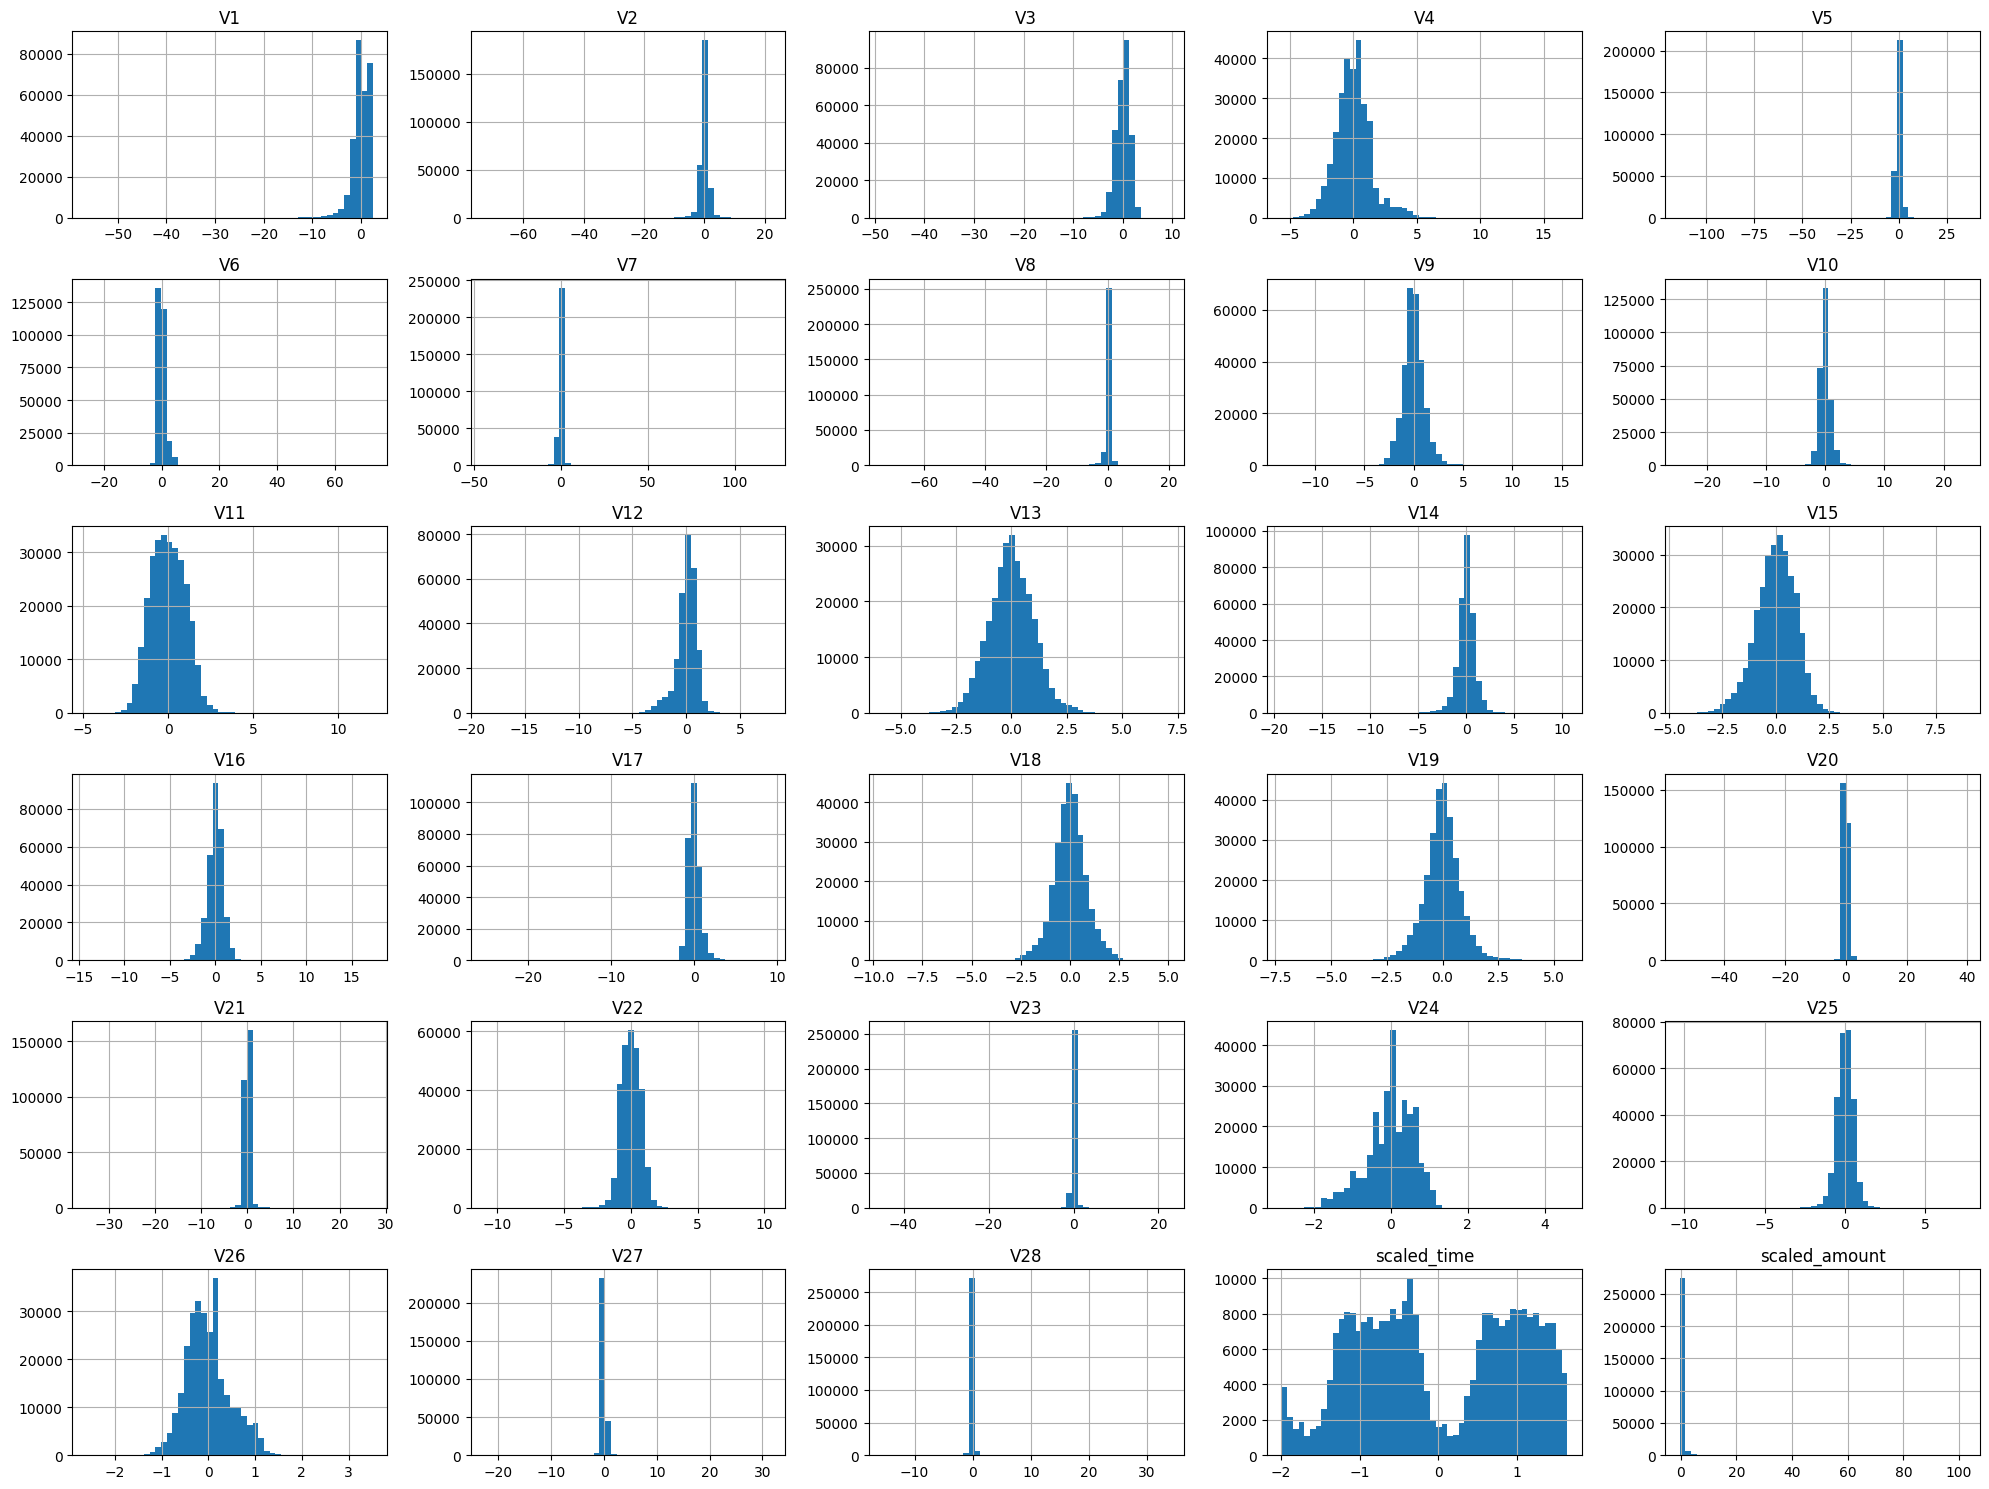

In [18]:
df.drop('Class', axis=1).hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

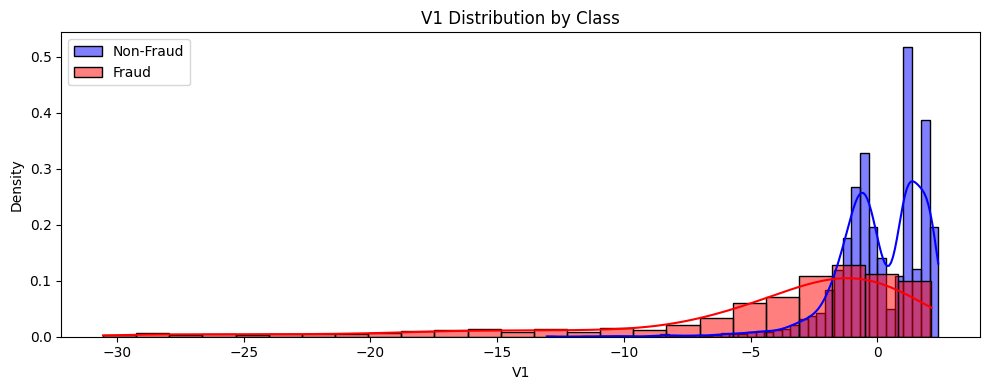

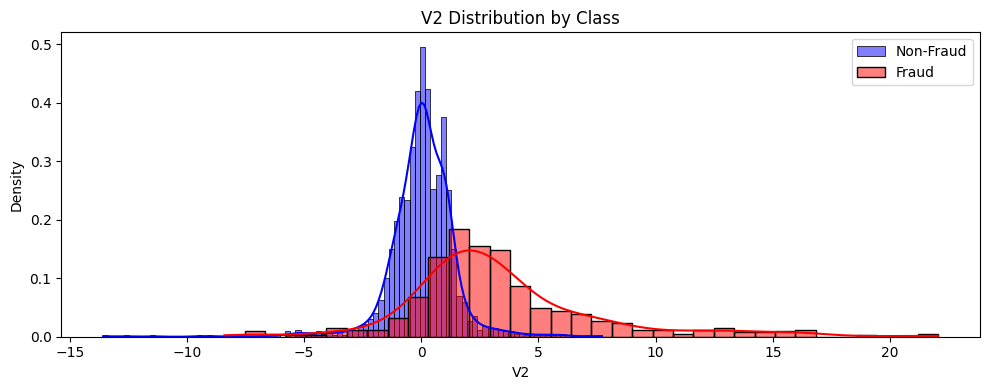

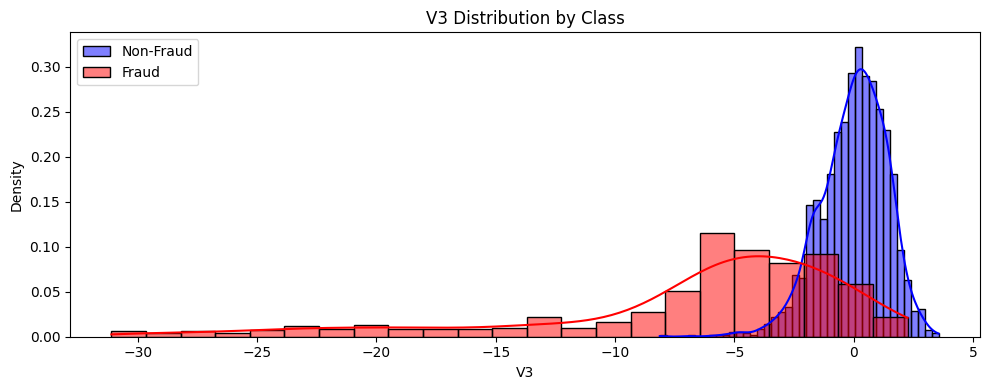

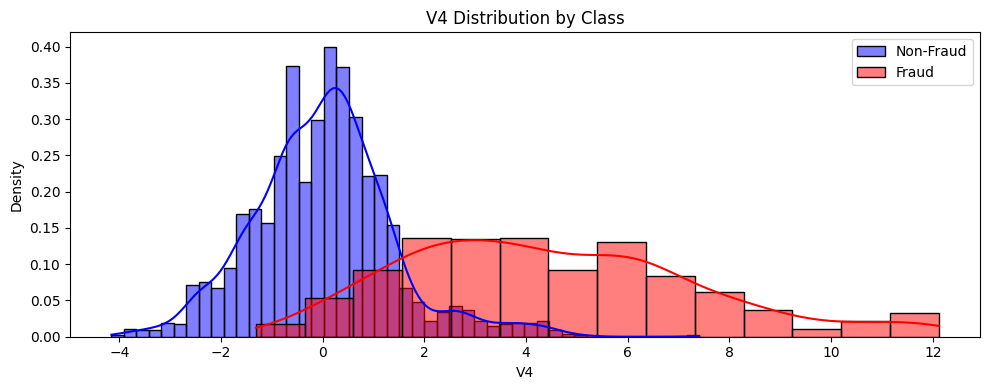

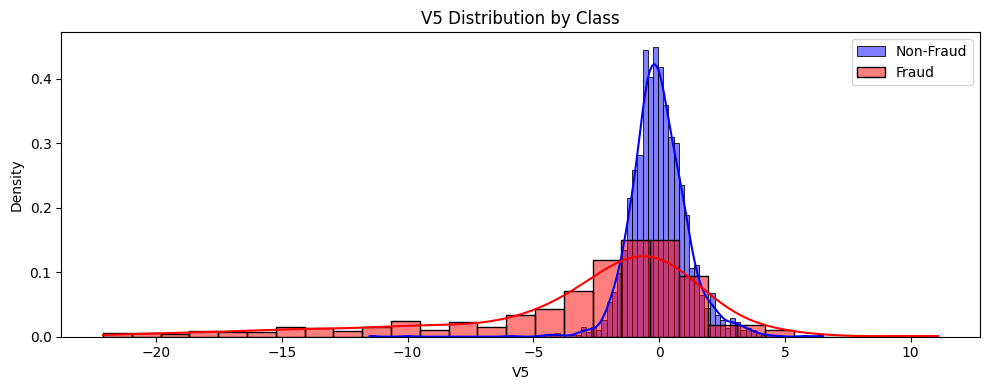

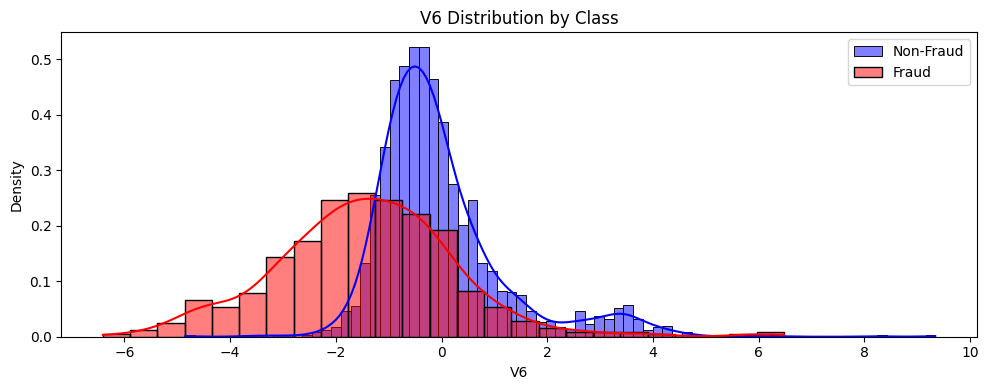

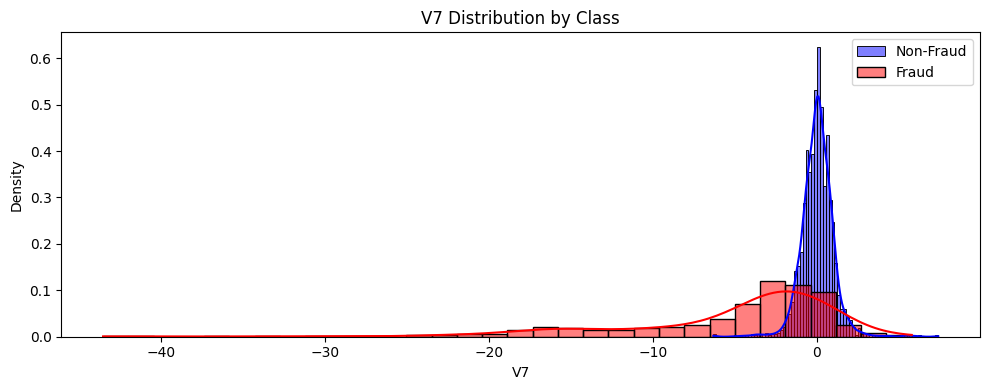

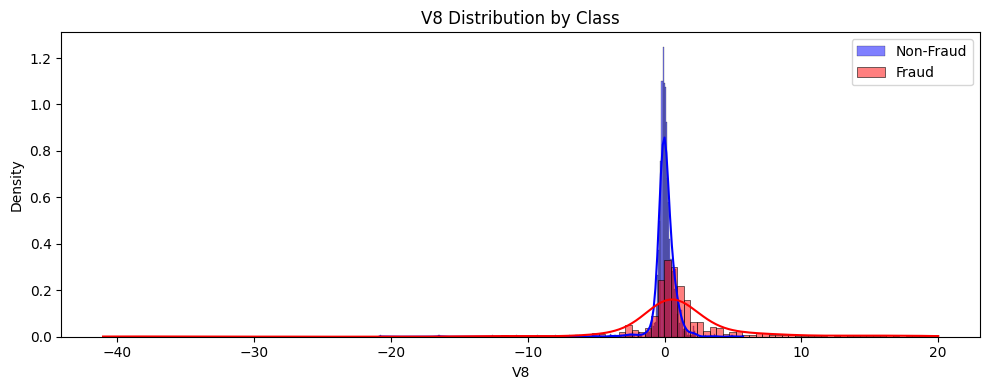

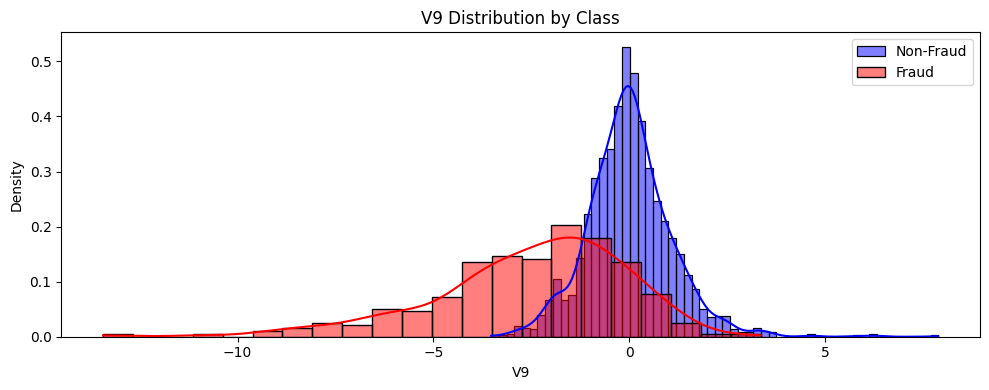

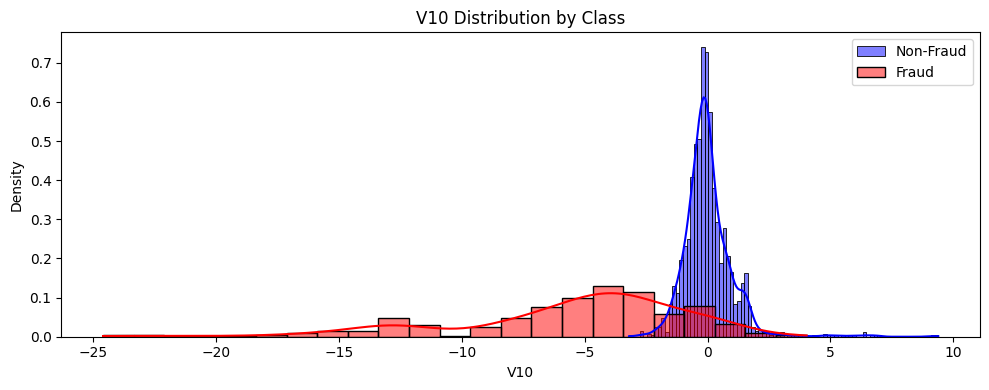

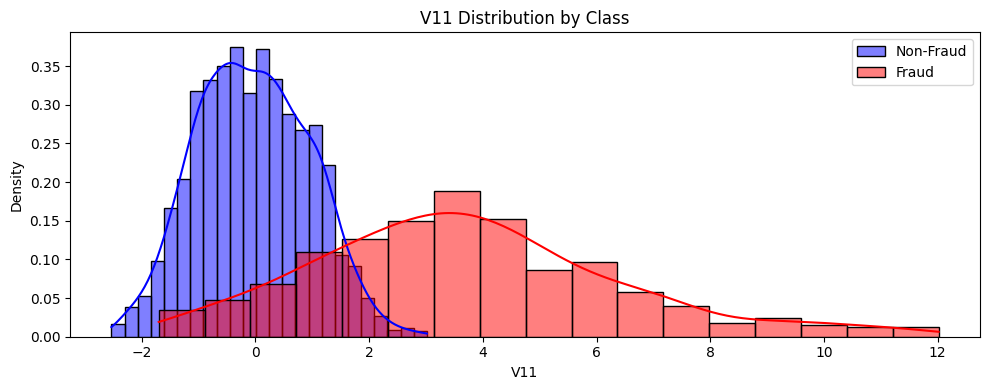

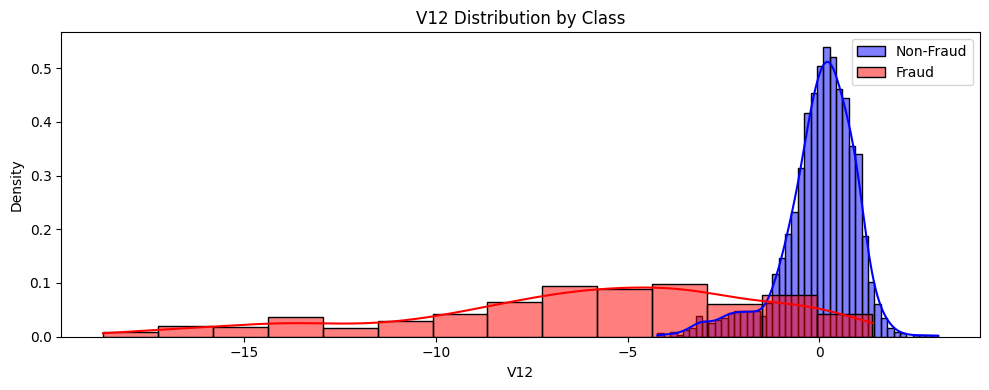

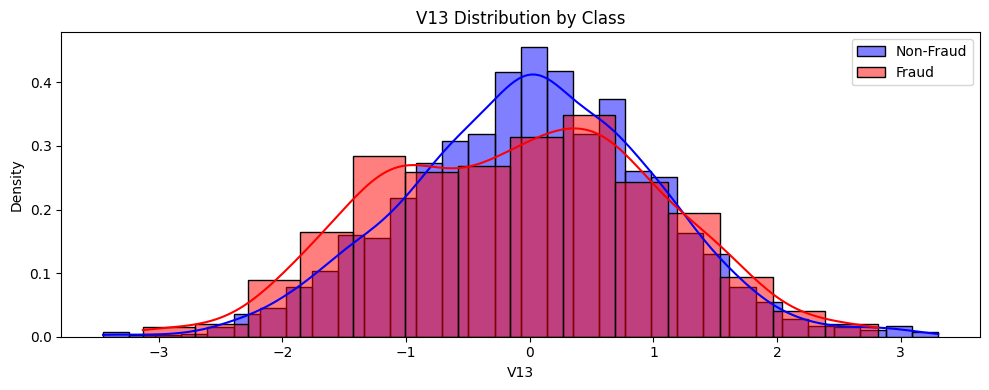

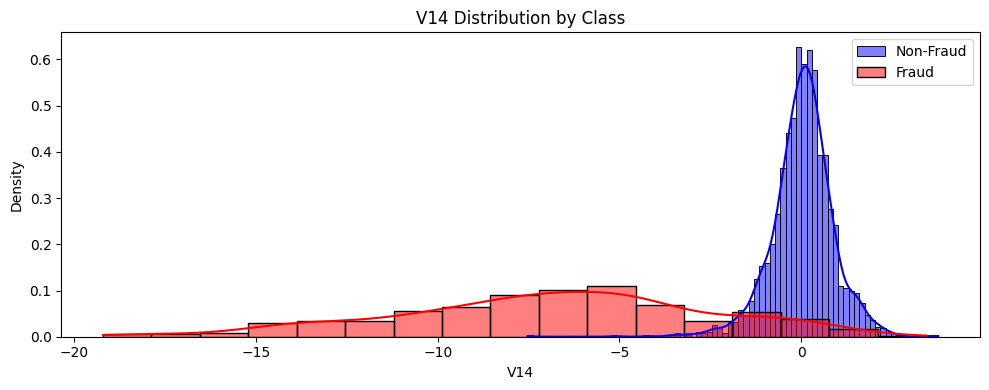

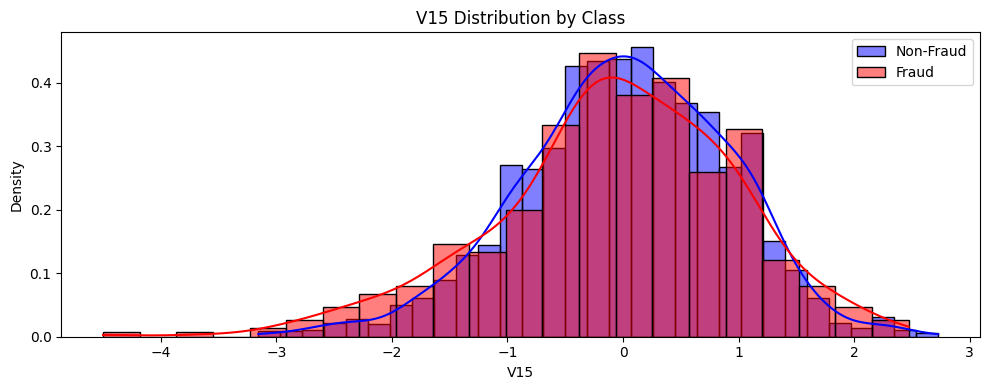

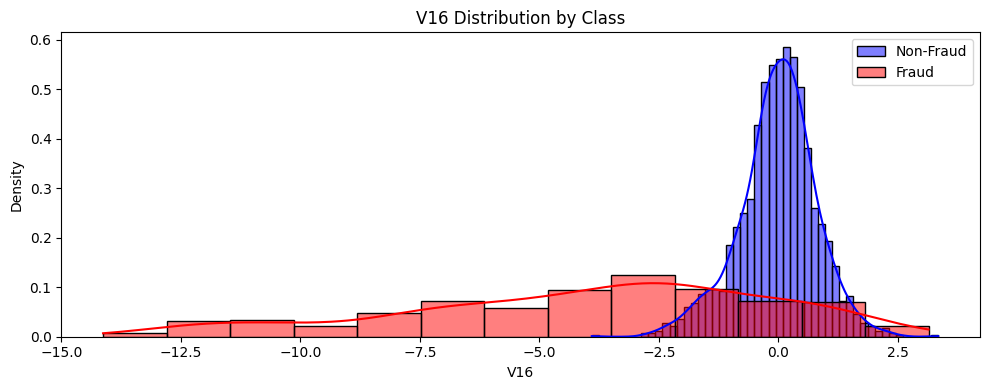

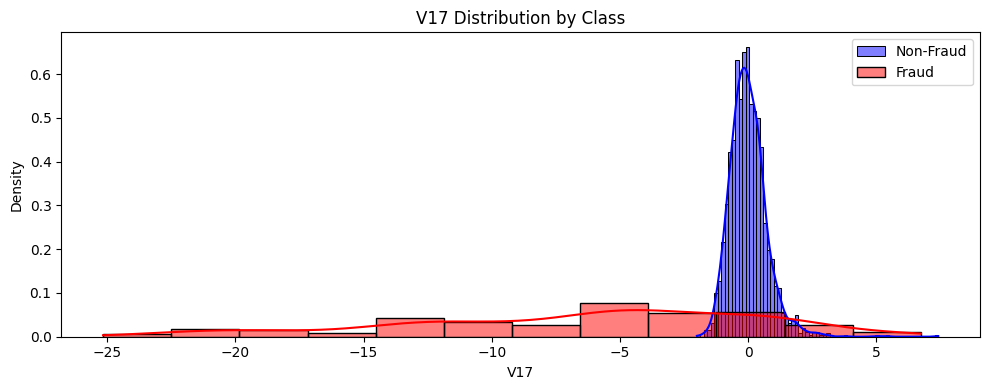

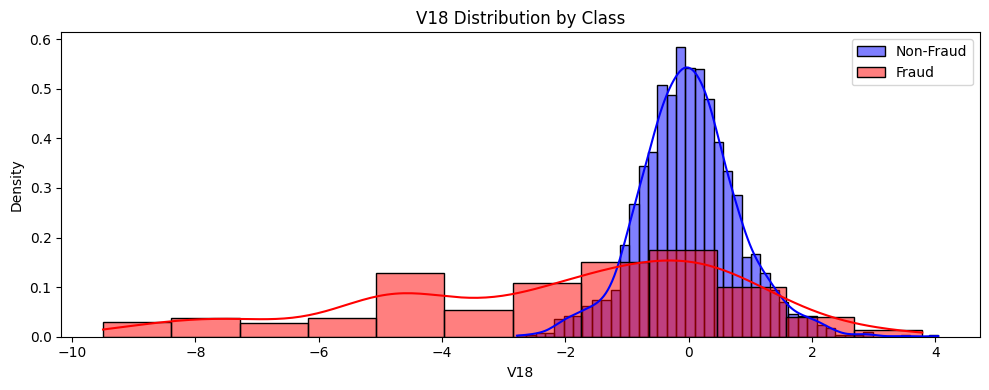

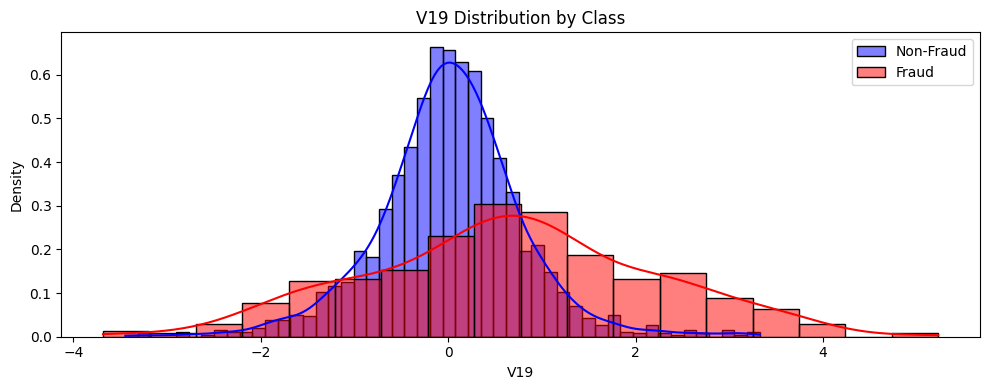

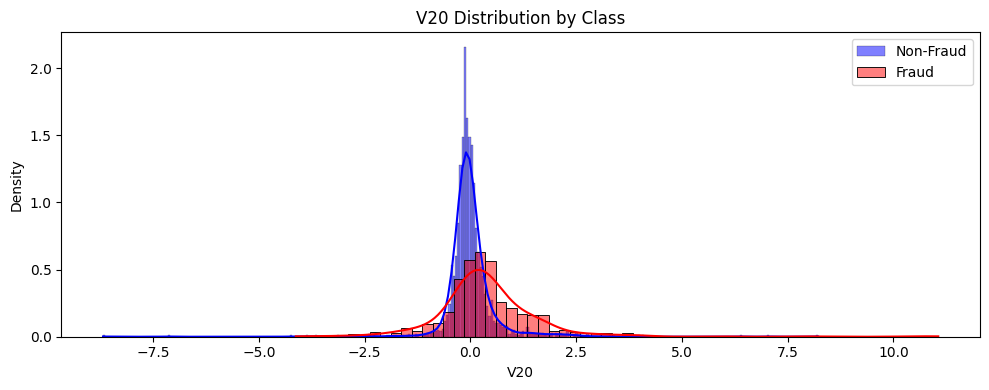

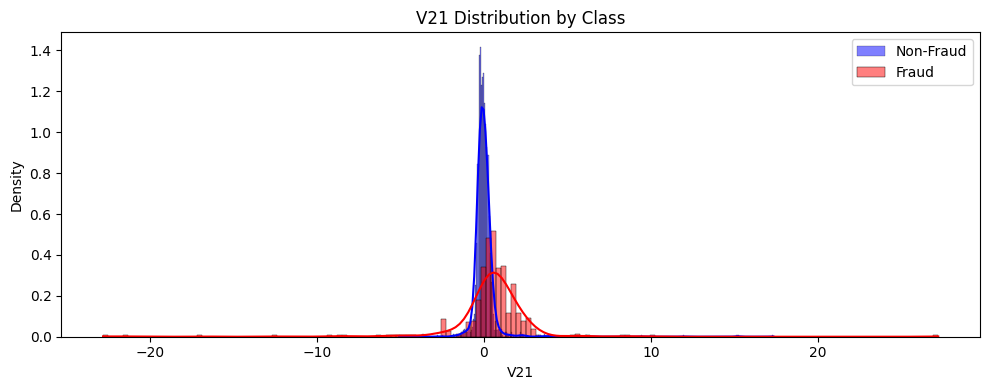

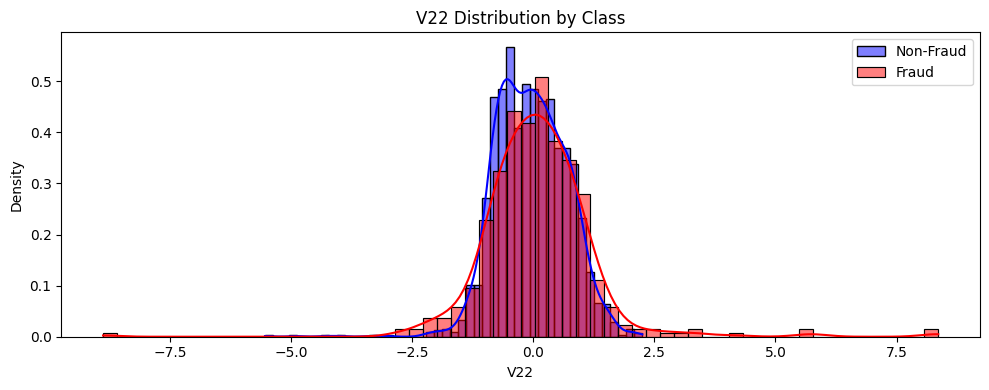

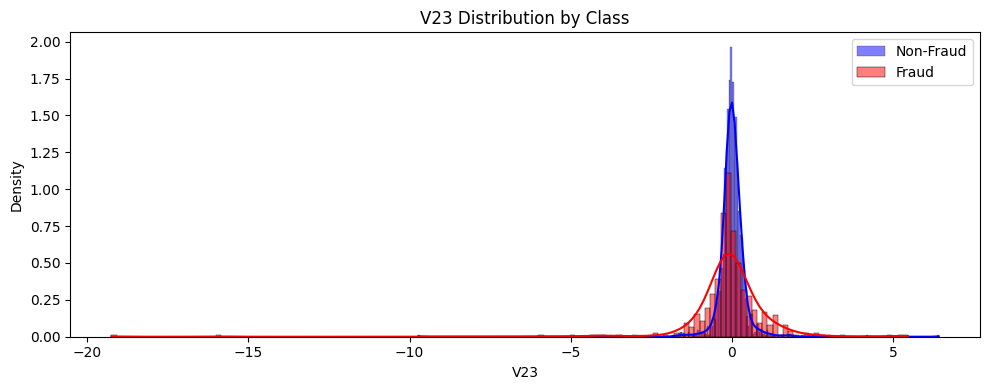

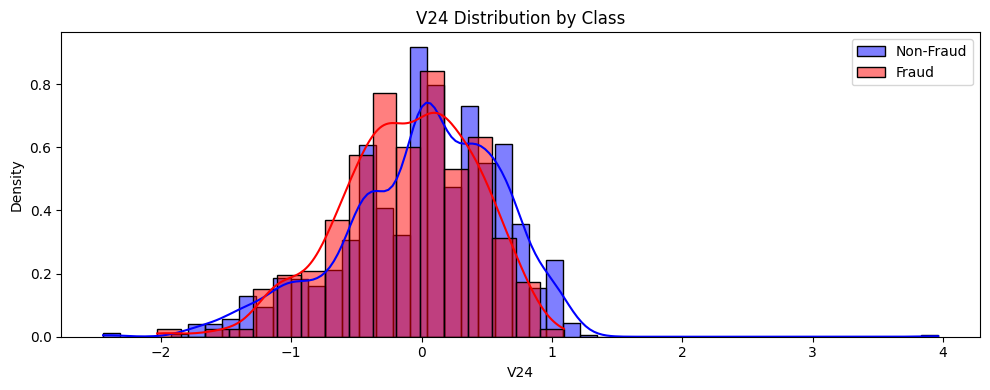

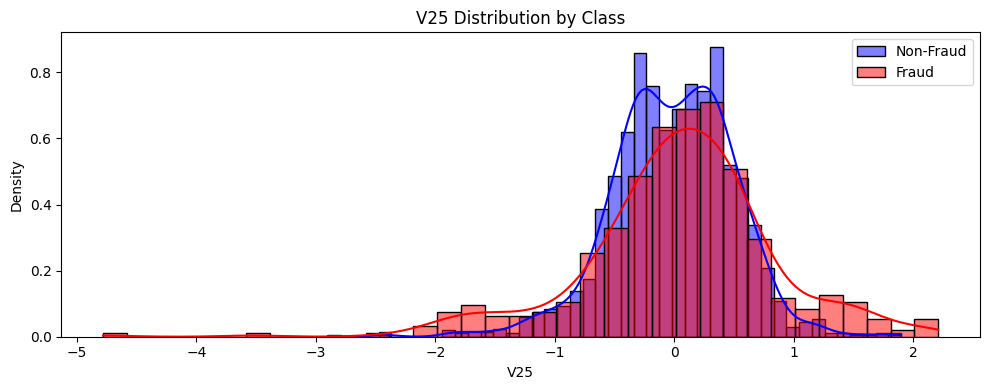

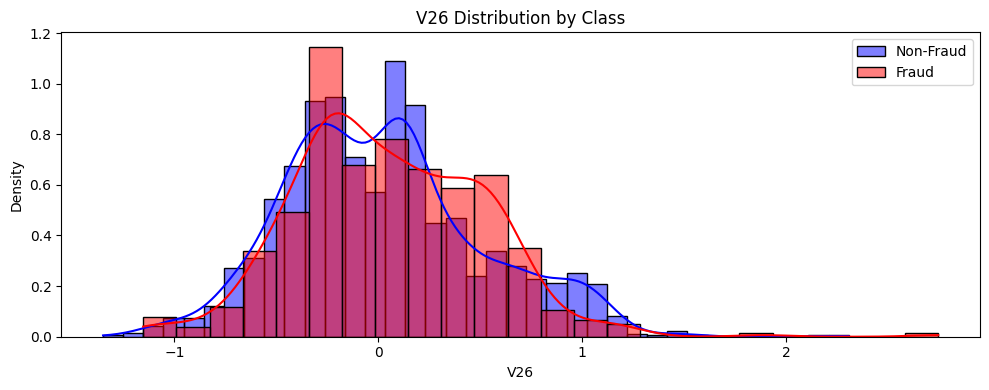

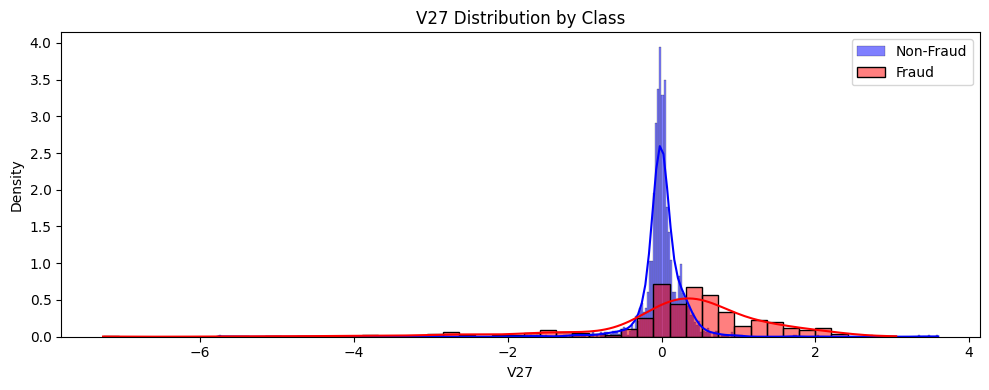

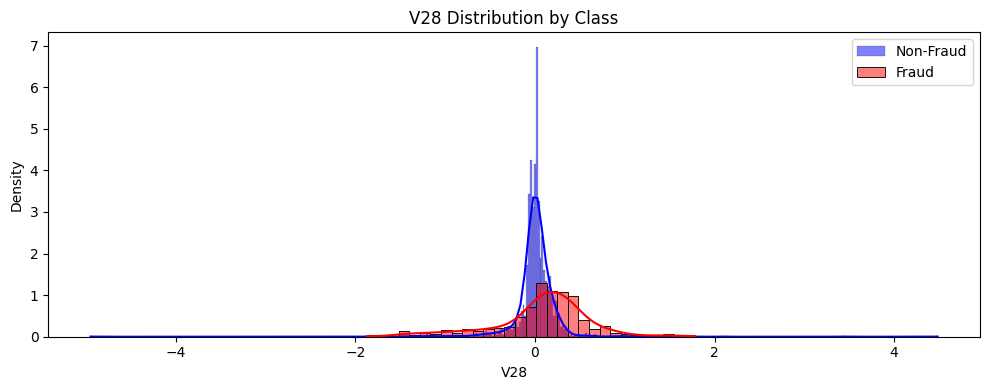

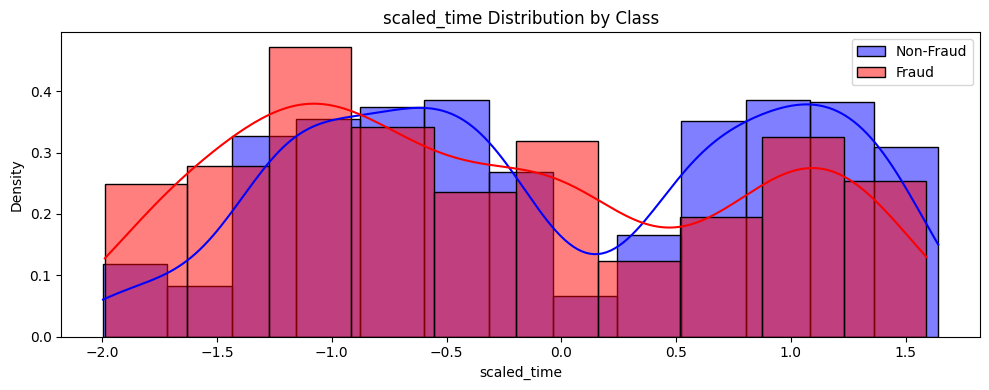

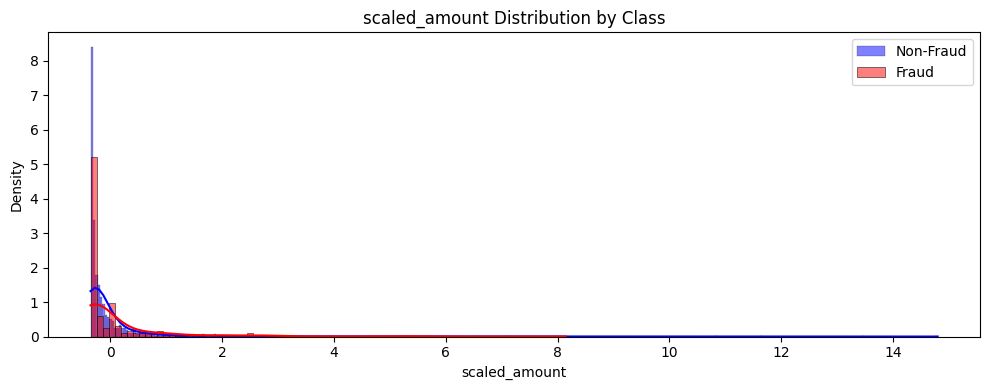

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in X_resampled.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_resampled[feature][y_resampled == 0], color="blue", label="Non-Fraud", kde=True, stat="density")
    sns.histplot(X_resampled[feature][y_resampled == 1], color="red", label="Fraud", kde=True, stat="density")
    plt.title(f'{feature} Distribution by Class')
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


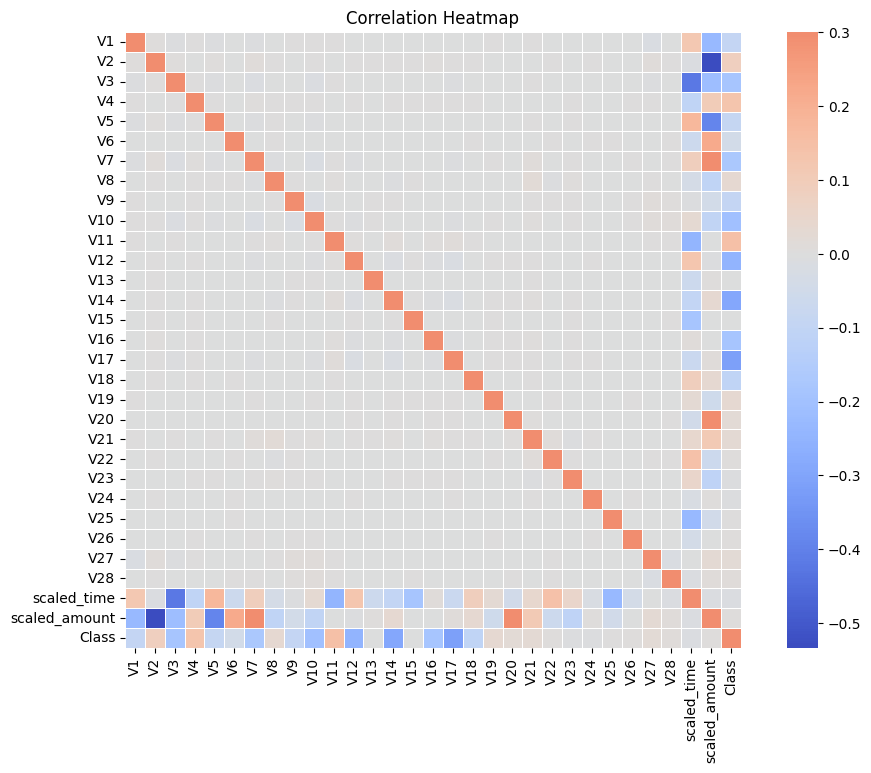

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', vmax=0.3, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


FEATURE SELECTION

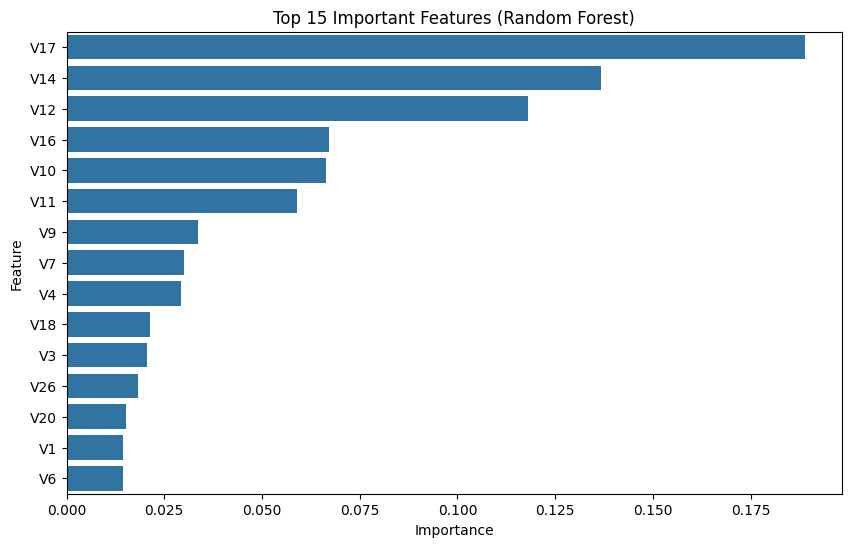

In [21]:
#Random Forest	(Embedded)	:Handles feature ranking during training

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
y_train = y_train['Class']
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns

# Create a dataframe
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Important Features (Random Forest)')
plt.show()


In [22]:
#ANOVA F-test	(Filter)	: Simple statistical test for numeric features
from sklearn.feature_selection import f_classif, SelectKBest

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-score': selector.scores_
}).sort_values(by='F-score', ascending=False)

print(anova_df.head(15))


   Feature       F-score
16     V17  24898.372568
13     V14  22051.937514
11     V12  15832.071788
9      V10  10901.888577
15     V16   8450.783428
2       V3   8241.061388
6       V7   7387.864608
10     V11   5276.589817
3       V4   4054.170473
17     V18   2629.804059
8       V9   2165.865710
0       V1   2158.516088
4       V5   1874.598792
1       V2   1795.105230
5       V6    447.077196


#MODEL

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Ensure you have a proper train/test split (if not already done)
# Split your dataset into training and test sets if you haven't done so already.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the KNN classifier with n_neighbors=5
knn = KNeighborsClassifier(n_neighbors=5)

# Perform cross-validation on the training data
cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation

# Store the accuracy scores from cross-validation
history = {
    'accuracy': cv_scores,  # Store cross-validation accuracy scores
}

# Print the mean accuracy from cross-validation
print(f"Cross-validation accuracy: {np.mean(cv_scores):.2f}")

# Train the KNN classifier on the full training data
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Ensure y_test contains only the 'Class' column and is of the correct data type
y_test = y_test.astype(int)  # Convert to integer type if necessary

# Evaluate the model with confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Evaluate test accuracy
test_accuracy = knn.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")


Cross-validation accuracy: 1.00
[[56653     3]
 [   25    65]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.96      0.72      0.82        90

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Test Accuracy: 1.00


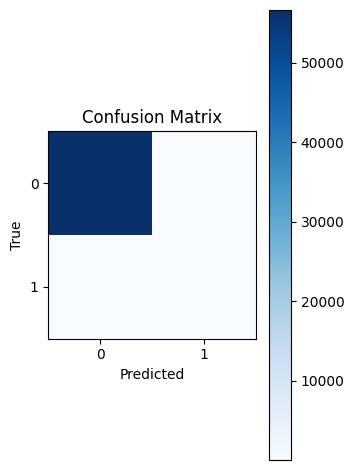

In [24]:
# Optional: If you want to plot the confusion matrix heatmap
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(cm.shape[1]), np.arange(cm.shape[1]))
plt.yticks(np.arange(cm.shape[0]), np.arange(cm.shape[0]))

plt.tight_layout()
plt.show()

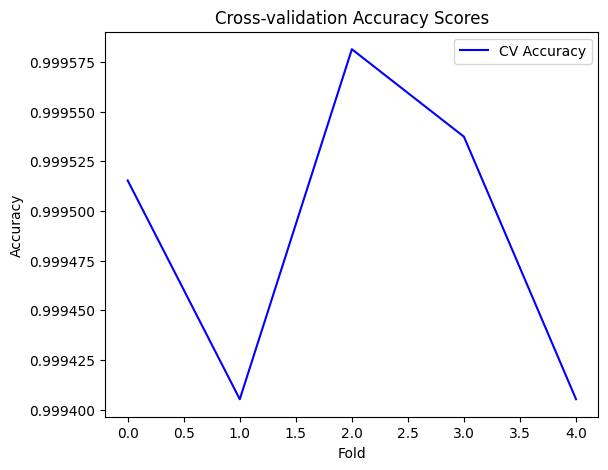

In [25]:
# Plotting cross-validation scores
plt.figure(figsize=(14, 5))

# Cross-validation accuracy plot
plt.subplot(1, 2, 1)
plt.plot(cv_scores, label='CV Accuracy', color='blue')
plt.title('Cross-validation Accuracy Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()




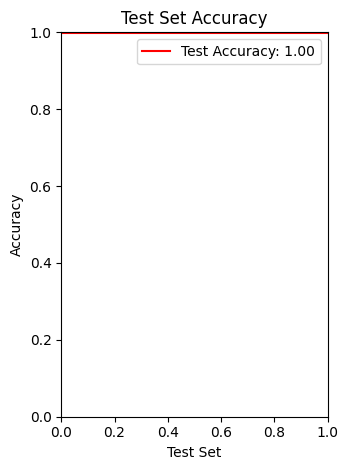

In [26]:
# Final Test accuracy plot
plt.subplot(1, 2, 2)
# We calculate the accuracy on the test set after training the model
test_accuracy = np.mean(cross_val_score(knn, X_test, y_test, cv=5, scoring='accuracy'))
plt.axhline(test_accuracy, color='red', label=f'Test Accuracy: {test_accuracy:.2f}')
plt.title('Test Set Accuracy')
plt.xlabel('Test Set')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# **Shap**

In [35]:
# SHAP Explanation
# Find one clean example of each digit
digit_indices = {digit: None for digit in range(10)}  # Assuming you have 10 classes (digits 0-9)
for i in range(len(X_test)):
    # Get the true label using .iloc to access by position
    true_label = y_test.iloc[i]

    # Ensure true_label is an integer within your expected class range
    if 0 <= true_label < 10:  # Adjust range if needed
        if digit_indices[true_label] is None:
            digit_indices[true_label] = i
        if all(v is not None for v in digit_indices.values()):
            break
    else:
        print(f"Warning: Unexpected class label {true_label} encountered at index {i}")

<Figure size 640x480 with 0 Axes>

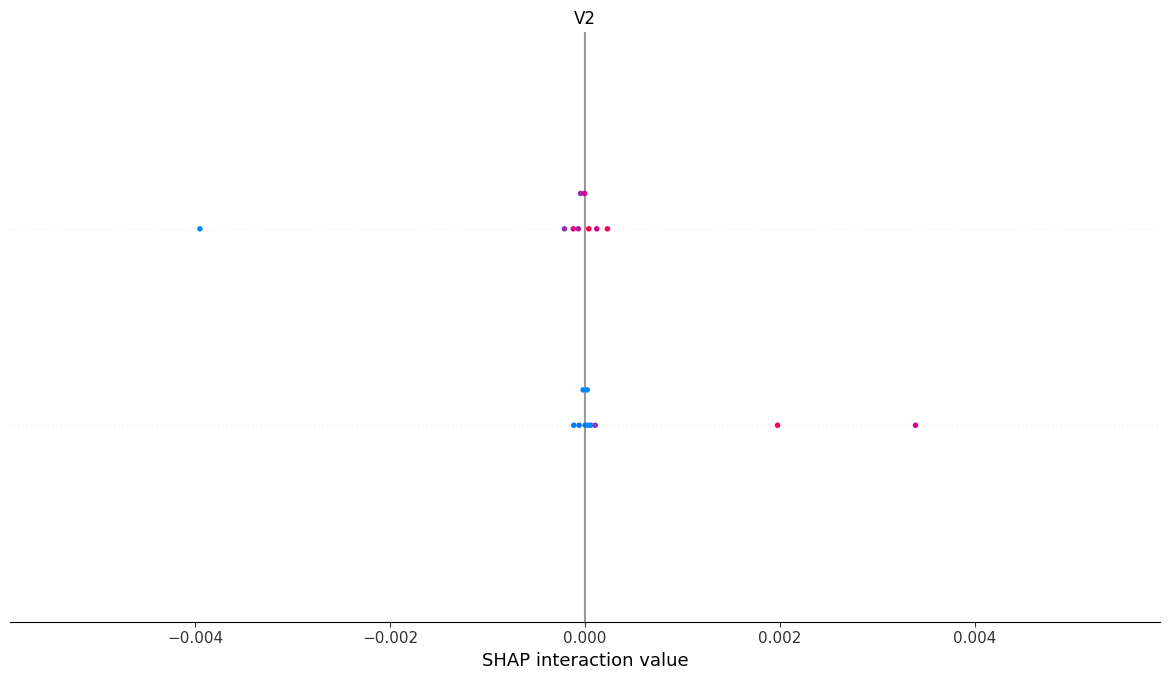

In [36]:
!pip install shap
import shap
import numpy as np

# Assuming X_test contains your test data
# Select 10 random samples from X_test as test_images
test_images = X_test.iloc[np.random.choice(X_test.shape[0], 10, replace=False)]

# Prepare data for SHAP
# Change this line to select rows instead of columns
background = X_train.iloc[np.random.choice(X_train.shape[0], 100, replace=False)]

# Create SHAP explainer using TreeExplainer for your RandomForest model
explainer = shap.TreeExplainer(model, background)  # Use TreeExplainer for tree-based models

# Get SHAP values
shap_values = explainer.shap_values(test_images)

# For a tabular dataset, you might want to use:
shap.summary_plot(shap_values, test_images)

# **ICE**

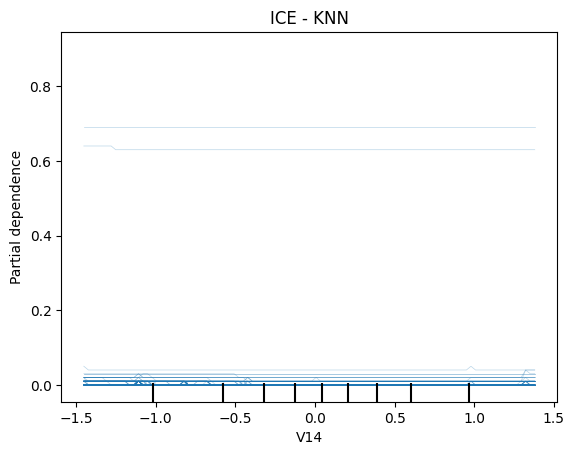

In [37]:
# ICE is included with PDP in sklearn
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
knn = model
feature = 'V14'
target_class = 1
PartialDependenceDisplay.from_estimator(knn, X_test, features=[feature], target=target_class, kind='individual') # features needs to be a sequence
plt.title("ICE - KNN")
plt.show()

# **PDP**

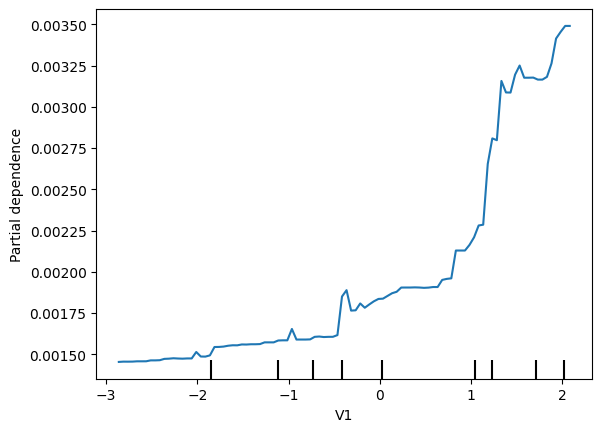

In [40]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(knn, X_test, features=feature, target=target_class)
plt.show()

In [41]:
from sklearn.inspection import partial_dependence

results = partial_dependence(knn, X_test, [0])
print(results["average"])
print(" ---------------------------------------------------------- ")
print(results["grid_values"])

[[0.00145314 0.0014549  0.00145473 0.00145508 0.00145684 0.00145684
  0.00145702 0.00146248 0.00146248 0.00146354 0.00147165 0.00147288
  0.00147535 0.00147376 0.00147288 0.00147429 0.00147429 0.00151341
  0.00148592 0.00148539 0.00149279 0.00154354 0.00154407 0.00154619
  0.0015513  0.00155412 0.00155377 0.00155905 0.00155852 0.00156029
  0.00156029 0.00156134 0.00157174 0.00157174 0.00157174 0.00158302
  0.00158408 0.00158408 0.00165298 0.00158883 0.00158883 0.00158883
  0.00158972 0.00160522 0.00160716 0.00160399 0.00160522 0.0016054
  0.0016158  0.00184965 0.00188824 0.00176435 0.00176612 0.0018077
  0.00178162 0.00180189 0.00182075 0.00183502 0.00183678 0.00185335
  0.00186974 0.00187837 0.0019041  0.00190428 0.00190428 0.00190516
  0.00190428 0.00190234 0.00190375 0.00190727 0.00190727 0.00195045
  0.00195661 0.00195996 0.00212861 0.00212861 0.00212861 0.00216297
  0.00220897 0.00228034 0.00228527 0.00265358 0.00280848 0.00279755
  0.00315687 0.00308709 0.00308638 0.00319476 0.00

# Permutation Feature **Importance**

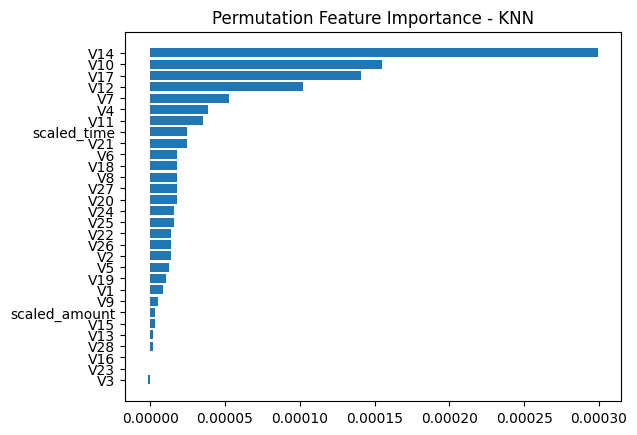

In [46]:
from sklearn.inspection import permutation_importance

result = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.barh(X_test.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - KNN")
plt.show()